In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [10]:
df = pd.read_excel('/kaggle/input/datasets/impuneetmishra/ct-data/preprocessed_patient_data_existingCTs.xlsx', sheet_name='Sheet1')
df.head()

,Unnamed: 0,ID,KeptInTrial,KeepinAnalysis,lesion PR,GM quality,WM,CT date (MM/DD/YYYYY),Pathname,Date of entering the pool,...,N19Nnr,S19Nnr,N20Nnw,S20Nnw,N21Nca,S21Nca,N22Pfc,S22PfcA,N23Lic,S23Lic
0,0.0,2001.0,1.0,1.0,r crblm,++,++,NaN,/home/data/patient_data/CT/CT_seg8/CT P2001/sw...,NaN,...,1.0,9.0,1.0,0.0,1.0,0.0,1.0,37.0,1.0,3.0
1,1.0,2002.0,1.0,1.0,L tmp,++,++,NaN,/home/data/patient_data/CT/CT_seg8/CT P2002/sw...,NaN,...,1.0,0.0,1.0,1.0,1.0,0.0,1.0,32.0,1.0,3.0
2,2.0,2003.0,1.0,1.0,R prtl Lpartl(atrophy),++,++,NaN,/home/data/patient_data/CT/CT_seg8/CT P2003/sw...,NaN,...,1.0,5.0,1.0,1.0,1.0,3.0,1.0,12.0,1.0,3.0
3,3.0,2004.0,1.0,1.0,R TPJ,++,++,NaN,/home/data/patient_data/CT/CT_seg8/CT P2004/sw...,NaN,...,1.0,9.0,1.0,2.0,1.0,3.0,1.0,24.0,1.0,3.0
4,4.0,2005.0,1.0,1.0,atrophy,++,++,NaN,/home/data/patient_data/CT/CT_seg8/CT P2005/sw...,NaN,...,1.0,8.0,1.0,5.0,1.0,3.0,1.0,39.0,1.0,3.0


### Pre-processing

In [11]:
df_subset = df.dropna(subset=['S2Lpn'])
df_subset = df_subset.select_dtypes(include=[np.number]).copy()
df_subset.head()

,Unnamed: 0,ID,KeptInTrial,KeepinAnalysis,F16gend,F17hand,F18educ,year,F19ethn,F34type,...,N19Nnr,S19Nnr,N20Nnw,S20Nnw,N21Nca,S21Nca,N22Pfc,S22PfcA,N23Lic,S23Lic
0,0.0,2001.0,1.0,1.0,1.0,2.0,2.0,12.0,NaN,4.0,...,1.0,9.0,1.0,0.0,1.0,0.0,1.0,37.0,1.0,3.0
1,1.0,2002.0,1.0,1.0,2.0,2.0,2.0,12.0,NaN,4.0,...,1.0,0.0,1.0,1.0,1.0,0.0,1.0,32.0,1.0,3.0
2,2.0,2003.0,1.0,1.0,1.0,2.0,2.0,12.0,NaN,4.0,...,1.0,5.0,1.0,1.0,1.0,3.0,1.0,12.0,1.0,3.0
3,3.0,2004.0,1.0,1.0,1.0,2.0,2.0,12.0,NaN,4.0,...,1.0,9.0,1.0,2.0,1.0,3.0,1.0,24.0,1.0,3.0
4,4.0,2005.0,1.0,1.0,1.0,2.0,2.0,12.0,NaN,4.0,...,1.0,8.0,1.0,5.0,1.0,3.0,1.0,39.0,1.0,3.0


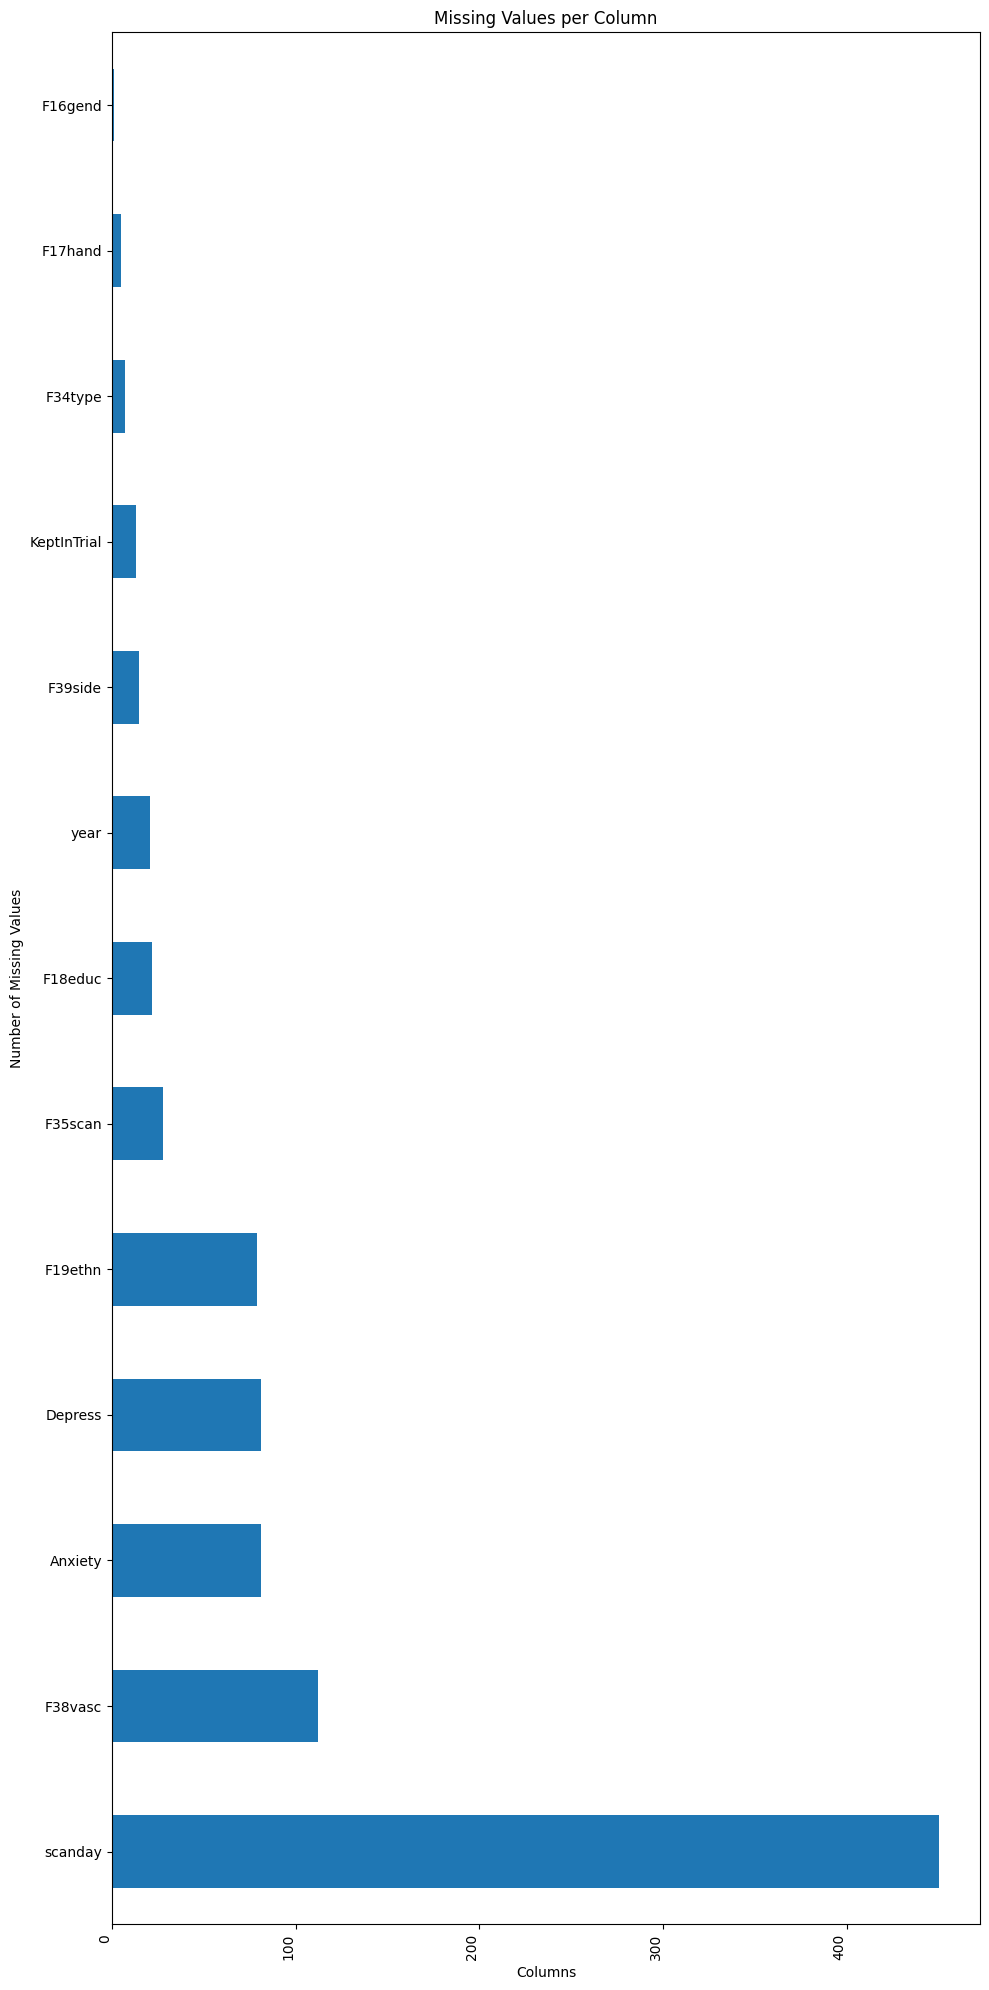

In [12]:
import matplotlib.pyplot as plt

# Count missing values per column
missing = df_subset.isnull().sum()

# Keep only columns with at least one missing value (optional)
missing = missing[missing > 0]

# Plot
plt.figure(figsize=(10,20))
missing.sort_values(ascending=False).plot(kind='barh')
plt.title('Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

In [13]:
df_subset = df_subset.drop(columns=['Unnamed: 0', 'scanday'])
df_subset = df_subset.fillna(df_subset.median())

--- TENSOR METRICS ---
Dimensions:      (453, 256, 256)
Data Type:       float64
Global Min:      -0.06
Global Max:      0.93
Global Mean:     0.0937
Global Std Dev:  0.1787

--- CORRUPTION AUDIT ---
PASS: Tensor contains zero non-finite values.


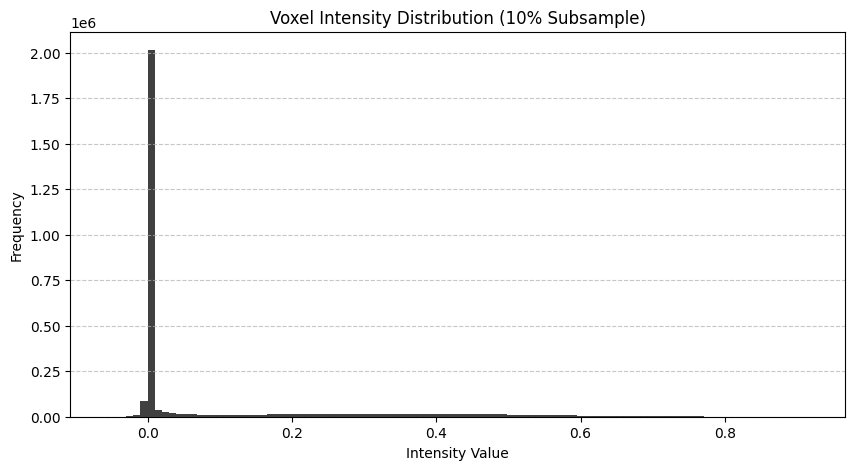

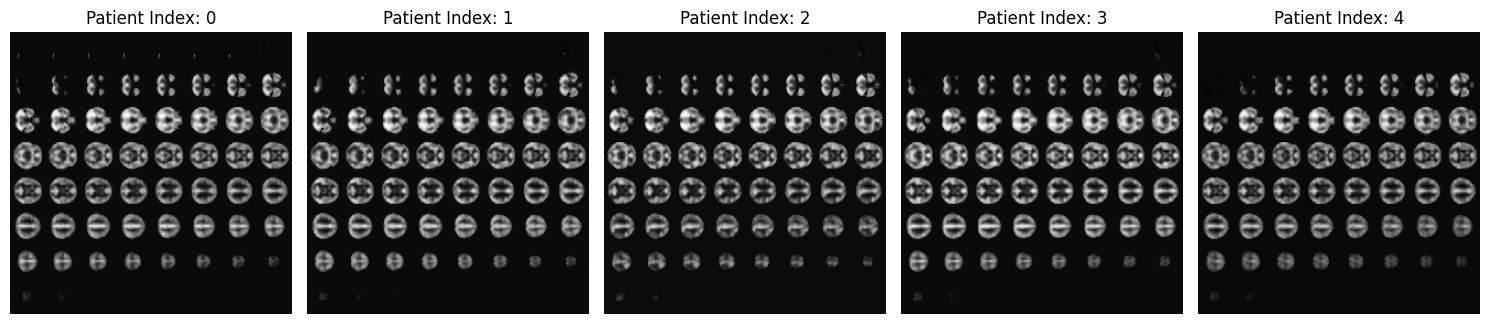

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Memory Load
file_path = "/kaggle/input/datasets/impuneetmishra/ct-data/stitched_CT_scans_BCoS.npy"
ct_array = np.load(file_path)

# 2. Structural & Statistical Extraction
print("--- TENSOR METRICS ---")
print(f"Dimensions:      {ct_array.shape}")
print(f"Data Type:       {ct_array.dtype}")
print(f"Global Min:      {np.min(ct_array):.2f}")
print(f"Global Max:      {np.max(ct_array):.2f}")
print(f"Global Mean:     {np.mean(ct_array):.4f}")
print(f"Global Std Dev:  {np.std(ct_array):.4f}")

# 3. Corruption Audit
print("\n--- CORRUPTION AUDIT ---")
nan_count = np.isnan(ct_array).sum()
inf_count = np.isinf(ct_array).sum()
if nan_count > 0 or inf_count > 0:
    print(f"FAIL: Detected {nan_count} NaNs and {inf_count} Infs. Imputation or masking required.")
else:
    print("PASS: Tensor contains zero non-finite values.")

# 4. Global Intensity Distribution
# Flatten a 10% subset to prevent RAM exhaustion during histogram binning
flattened_subset = ct_array[::10].flatten()

plt.figure(figsize=(10, 5))
plt.hist(flattened_subset, bins=100, color='black', alpha=0.75)
plt.title("Voxel Intensity Distribution (10% Subsample)")
plt.xlabel("Intensity Value")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 5. Visual Verification Montage
num_samples = min(5, ct_array.shape[0])
fig, axes = plt.subplots(1, num_samples, figsize=(15, 4))
if num_samples == 1:
    axes = [axes]

for i in range(num_samples):
    axes[i].imshow(ct_array[i], cmap='gray')
    axes[i].set_title(f"Patient Index: {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Pipeline

In [15]:
import numpy as np
import pandas as pd
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Device and Model Initialization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet_extractor = torch.nn.Sequential(*list(resnet.children())[:-1]).to(device)
resnet_extractor.eval()
for param in resnet_extractor.parameters():
    param.requires_grad = False

# 2. Extract Latent Vectors for the Entire Baseline Tensor
ct_array = np.load("stitched_CT_scans_BCoS.npy") # Shape: (452, 256, 256)
ct_tensor = torch.tensor(ct_array, dtype=torch.float32).unsqueeze(1).repeat(1, 3, 1, 1)
ct_tensor = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(ct_tensor)

dataloader = DataLoader(TensorDataset(ct_tensor), batch_size=32, shuffle=False)
cnn_features = []
with torch.no_grad():
    for batch in dataloader:
        output = resnet_extractor(batch[0].to(device))
        cnn_features.append(output.view(output.size(0), -1).cpu().numpy())
cnn_features_global = np.vstack(cnn_features) 

# 3. Temporal Data Alignment (Prognostic Constraint)
df_base = pd.read_excel("preprocessed_patient_data_existingCTs.xlsx", sheet_name='Sheet1')
df_base['tensor_idx'] = df_base.index # Cache array map

df_followup = pd.read_excel("preprocessed_BUCS_patient_data_followUp.xlsx", sheet_name='Sheet1')

# Inner join strictly on patients existing in both epochs
df_merged = pd.merge(df_base, df_followup, on='ID', how='inner', suffixes=('_base', '_followup'))
# Assuming your DataFrame is named df
df_merged = df_merged.select_dtypes(include=['number'])
df_merged = df_merged.dropna(subset=['S2Lpn', 'S2Lpn_fu'])
df_merged = df_merged.fillna(df_merged.median())

# Isolate valid indices and slice the CNN feature matrix
valid_indices = df_merged['tensor_idx'].values
X_cnn_matched = cnn_features_global[valid_indices]

# Define Predictors (Baseline) and Target (Follow-up)
# Adjust 'S2Lpn_followup' to match your actual column name
y = df_merged['S2Lpn_fu'].values 

# Drop ID, tensor map, and ALL follow-up columns to prevent temporal leakage
drop_cols = [col for col in df_merged.columns if col.endswith('_followup')] + ['ID', 'tensor_idx']
X_metadata = df_merged.drop(columns=drop_cols).values

# 4. K-Fold Cross-Validation Setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)
epochs = 150

r2_scores = []
mae_scores = []
fold_train_errors = np.zeros((5, epochs))
fold_val_errors = np.zeros((5, epochs))

for fold_idx, (train_index, test_index) in enumerate(kf.split(X_cnn_matched)):
    X_meta_train, X_meta_test = X_metadata[train_index], X_metadata[test_index]
    X_cnn_train, X_cnn_test = X_cnn_matched[train_index], X_cnn_matched[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Dynamic Baseline Feature Selection
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_meta_train, y_train)
    top_20_indices = np.argsort(rf.feature_importances_)[-20:]
    
    X_meta_train_selected = X_meta_train[:, top_20_indices]
    X_meta_test_selected = X_meta_test[:, top_20_indices]
    
    # Modality Fusion
    X_train_fused = np.hstack((X_cnn_train, X_meta_train_selected))
    X_test_fused = np.hstack((X_cnn_test, X_meta_test_selected))
    
    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fused)
    X_test_scaled = scaler.transform(X_test_fused)
    
    # Regularized Regression
    model = SGDRegressor(penalty='l2', alpha=1.0, learning_rate='invscaling', max_iter=1, tol=None, random_state=42)
    
    for epoch in range(epochs):
        model.partial_fit(X_train_scaled, y_train)
        
        train_pred = model.predict(X_train_scaled)
        val_pred = model.predict(X_test_scaled)
        fold_train_errors[fold_idx, epoch] = mean_squared_error(y_train, train_pred)
        fold_val_errors[fold_idx, epoch] = mean_squared_error(y_test, val_pred)
    
    y_pred_final = model.predict(X_test_scaled)
    r2_scores.append(r2_score(y_test, y_pred_final))
    mae_scores.append(mean_absolute_error(y_test, y_pred_final))

# 5. Output and Learning Curves
print(f"Cohort Size After Inner Join: {len(df_merged)}")
print(f"Validated Prognostic Mean R2: {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"Validated Prognostic Mean MAE: {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")

mean_train_err = np.mean(fold_train_errors, axis=0)
mean_val_err = np.mean(fold_val_errors, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), mean_train_err, label='Train Error (MSE)', color='blue')
plt.plot(range(1, epochs + 1), mean_val_err, label='Validation Error (MSE)', color='orange')
plt.title('Prognostic SGD Regressor (L2 Penalty) Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('learning_curve_01.png', dpi=600)
plt.show()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


URLError: <urlopen error [Errno -3] Temporary failure in name resolution>

## Predicting from tabular data alone

In [16]:
import pandas as pd
import numpy as np
import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [17]:
df_init = pd.read_excel('/kaggle/input/datasets/impuneetmishra/ct-data/preprocessed_patient_data_existingCTs.xlsx', sheet_name='Sheet1')
print(df_init.info())
print(df_init.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Columns: 112 entries, Unnamed: 0 to S23Lic
dtypes: datetime64[ns](2), float64(88), object(22)
memory usage: 400.0+ KB
None
['Unnamed: 0', 'ID', 'KeptInTrial', 'KeepinAnalysis', 'lesion PR', 'GM quality', 'WM', 'CT date (MM/DD/YYYYY)', 'Pathname', 'Date of entering the pool', 'Type of stroke', 'Scan – Date', 'F15age', 'F16gend', 'F17hand', 'F18educ', 'year', 'F19ethn', 'F2histo', 'F31stro', 'F32hosp', 'F34type', 'F35scan', 'scanday', 'F35date', 'F37les', 'F38vasc', 'F38spec', 'F39side', 'F310loc', 'spec. cort', 'spec.cort B', 'F4set1', 'F42Examiner', 'F43-Site', 'F45scre', 'Time (BcoS – Stroke)days', 'Barthel', 'Anxiety', 'Depress', 'N1Mpi', 'S1Mpi', 'N1MtsF', 'S1MtsF', 'N1MtsM', 'S1MtsM', 'N1Mno', 'S1Mno', 'N2Lpn', 'S2Lpn', 'N3Lsc', 'S3Lsc', 'N4Lsr', 'S4LsrA', 'S4LsrT', 'N5Lre', 'S5LreA', 'S5LreT', 'N61Mfi', 'S61Mfi', 'N62Mri', 'S62Mri', 'N7Akc', 'S7AkcA', 'S7AkcF', 'S7AkcS', 'N8Ave', 'S8AveLU', 'S8AveRU', 'S8AveLB

In [18]:
# dropping unnecessary
df_init = df_init.rename(columns={'Unnamed: 0': 'idx'})
df_init = df_init.dropna(subset=['S2Lpn'])

In [19]:
print(df_init.columns.tolist())
df_init.head(3)

['idx', 'ID', 'KeptInTrial', 'KeepinAnalysis', 'lesion PR', 'GM quality', 'WM', 'CT date (MM/DD/YYYYY)', 'Pathname', 'Date of entering the pool', 'Type of stroke', 'Scan – Date', 'F15age', 'F16gend', 'F17hand', 'F18educ', 'year', 'F19ethn', 'F2histo', 'F31stro', 'F32hosp', 'F34type', 'F35scan', 'scanday', 'F35date', 'F37les', 'F38vasc', 'F38spec', 'F39side', 'F310loc', 'spec. cort', 'spec.cort B', 'F4set1', 'F42Examiner', 'F43-Site', 'F45scre', 'Time (BcoS – Stroke)days', 'Barthel', 'Anxiety', 'Depress', 'N1Mpi', 'S1Mpi', 'N1MtsF', 'S1MtsF', 'N1MtsM', 'S1MtsM', 'N1Mno', 'S1Mno', 'N2Lpn', 'S2Lpn', 'N3Lsc', 'S3Lsc', 'N4Lsr', 'S4LsrA', 'S4LsrT', 'N5Lre', 'S5LreA', 'S5LreT', 'N61Mfi', 'S61Mfi', 'N62Mri', 'S62Mri', 'N7Akc', 'S7AkcA', 'S7AkcF', 'S7AkcS', 'N8Ave', 'S8AveLU', 'S8AveRU', 'S8AveLB', 'S8AveRB', 'N9Ate', 'S9AteLU', 'S9AteRU', 'S9AteLB', 'S9AteRB', 'N10Abf', 'S10AbfA', 'S10AbfR', 'N11Aaa', 'S11AaaA', 'S11AaaF', 'S11AaaO', 'S11AaaI', 'S11AaaP', 'S11AaaM', 'N121Mfd', 'S121Mfd', 'N122

,idx,ID,KeptInTrial,KeepinAnalysis,lesion PR,GM quality,WM,CT date (MM/DD/YYYYY),Pathname,Date of entering the pool,...,N19Nnr,S19Nnr,N20Nnw,S20Nnw,N21Nca,S21Nca,N22Pfc,S22PfcA,N23Lic,S23Lic
0,0.0,2001.0,1.0,1.0,r crblm,++,++,NaN,/home/data/patient_data/CT/CT_seg8/CT P2001/sw...,NaN,...,1.0,9.0,1.0,0.0,1.0,0.0,1.0,37.0,1.0,3.0
1,1.0,2002.0,1.0,1.0,L tmp,++,++,NaN,/home/data/patient_data/CT/CT_seg8/CT P2002/sw...,NaN,...,1.0,0.0,1.0,1.0,1.0,0.0,1.0,32.0,1.0,3.0
2,2.0,2003.0,1.0,1.0,R prtl Lpartl(atrophy),++,++,NaN,/home/data/patient_data/CT/CT_seg8/CT P2003/sw...,NaN,...,1.0,5.0,1.0,1.0,1.0,3.0,1.0,12.0,1.0,3.0


In [20]:
cols = ['F2histo', 'F37les','F310loc', 'F45scre', 'Barthel']  # your columns

mask = df_init[cols].map(lambda x: isinstance(x, str)).any(axis=1)

df_init = df_init[~mask]

In [21]:
# cols with datetime-like values but not datetime dtype
import datetime

cols_with_datetime_objects = [
    col for col in df_init.columns
    if df_init[col].dtype != 'datetime64[ns]'
    and df_init[col].apply(lambda x: isinstance(x, (datetime.datetime, datetime.date))).any()
]

for col in cols_with_datetime_objects:
     df_init[col] = pd.to_datetime(df_init[col],  errors='coerce')

In [22]:
# loading followup sheet
df_fu = pd.read_excel('/kaggle/input/datasets/impuneetmishra/ct-data/preprocessed_BUCS_patient_data_followUp.xlsx', sheet_name='Sheet1')
df_fu.head()

,Unnamed: 0,Directory,Type of stroke,Scan-date (round to 7),ID,F15age,F16gend,F17hand,F18educ,year,...,N19Nnr_fu,S19Nnr_fu,N20Nnw_fu,S20Nnw_fu,N21Nca_fu,S21Nca_fu,N22Pfc_fu,S22PfcA_fu,N23Lic_fu,S23Lic_fu
0,0,/home/data/patient_data/CT/CT_seg8/CT P2002/sw...,1.0,1.0,2002,68.0,2,2,2.0,NaN,...,1,9,1,1,1,0,1,37,1,3.0
1,1,/home/data/patient_data/CT/CT_seg8/CT P2003/sw...,1.0,7.0,2003,82.0,1,2,2.0,NaN,...,1,5,1,5,1,2,1,12,1,3.0
2,2,/home/data/patient_data/CT/CT_seg8/CT P2004/sw...,1.0,1.0,2004,61.0,1,2,3.0,NaN,...,5,0,5,0,5,0,5,0,1,3.0
3,3,/home/data/patient_data/CT/CT_seg8/CT P2008/sw...,1.0,1.0,2008,82.0,1,2,2.0,NaN,...,1,9,1,5,1,4,1,45,1,3.0
4,4,/home/data/patient_data/CT/CT_seg8/CT P2011/sw...,1.0,2.0,2011,81.0,1,2,5.0,NaN,...,1,8,1,4,1,2,1,39,1,3.0


In [23]:
# 1. Isolate target from follow-up and merge with baseline features
df_fu_target = df_fu[['ID', 'S2Lpn_fu']].copy()
df_merged = pd.merge(df_init, df_fu_target, on='ID', how='inner')

# 2. Preprocessing
def preprocess_prognostic(df):
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])
        
    df = df.dropna(subset=['S2Lpn_fu'])
    
    cols = ['F2histo', 'F37les', 'F310loc', 'F45scre', 'Barthel']
    cols_present = [c for c in cols if c in df.columns]
    mask = df[cols_present].map(lambda x: isinstance(x, str)).any(axis=1)
    df = df[~mask]
    
    cols_with_datetime = [
        col for col in df.columns
        if df[col].dtype != 'datetime64[ns]'
        and df[col].apply(lambda x: isinstance(x, (datetime.datetime, datetime.date))).any()
    ]
    for col in cols_with_datetime:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        
    df = df.select_dtypes(include=['number'])
    df = df.dropna(how='all', axis=1)  # Drop entirely NaN columns (like scanday)
    df = df.fillna(df.median())
    return df

df_clean = preprocess_prognostic(df_merged)
df_clean = df_clean.dropna(subset='S2Lpn_fu')
# 3. Define Features and Target
drop_cols = ['S2Lpn_fu', 'S2Lpn', 'ID', 'idx']
drop_cols = [c for c in drop_cols if c in df_clean.columns]

X = df_clean.drop(columns=drop_cols).values
y = df_clean['S2Lpn_fu'].values
X_tab = X
y_target = y

# 4. Three-Way Split (60% Train, 20% Validation, 20% Test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 5. Validation Fold Optimization (L2 Penalty Tuning)
alphas = np.logspace(-3, 4, 100)
best_alpha = None
best_val_r2 = -np.inf

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    val_preds = ridge.predict(X_val_scaled)
    val_r2 = r2_score(y_val, val_preds)
    
    if val_r2 > best_val_r2:
        best_val_r2 = val_r2
        best_alpha = alpha

# 6. Execution on Test Fold
best_ridge_tab_only = Ridge(alpha=best_alpha)
best_ridge_tab_only.fit(X_train_scaled, y_train)

y_pred = best_ridge_tab_only.predict(X_test_scaled)

print(f"Optimal L2 Penalty (Alpha): {best_alpha:.4f}")
print(f"Prognostic Ridge R2: {r2_score(y_test, y_pred):.4f}")
print(f"Prognostic Ridge MAE: {mean_absolute_error(y_test, y_pred):.4f}")

Optimal L2 Penalty (Alpha): 200.9233
Prognostic Ridge R2: 0.5160
Prognostic Ridge MAE: 1.3778


## ResNet-18 Experiments

In [24]:
!pip install torch torchvision

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision.transforms import transforms
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import torchvision.models as models
import numpy as np

# 1. Three-Way Data Partitioning
# Isolate 20% for Final Testing (Split 3)
idx_temp, idx_test = train_test_split(np.arange(len(y_target)), test_size=0.2, random_state=42)

# Partition remaining 80% into CNN Train (Split 1) and Ridge Train (Split 2)
# 0.25 * 0.8 = 0.2 (Leaves 60% for CNN, 20% for Ridge)
idx_cnn, idx_ridge = train_test_split(idx_temp, test_size=0.25, random_state=42) 
ct_array = np.load("/kaggle/input/datasets/impuneetmishra/ct-data/stitched_CT_scans_BCoS.npy") # Shape: (452, 256, 256)
ct_tensor = torch.tensor(ct_array, dtype=torch.float32).unsqueeze(1).repeat(1, 3, 1, 1)
ct_tensor = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(ct_tensor)

# Map arrays to splits
tensor_cnn, y_cnn = ct_tensor[idx_cnn], y_target[idx_cnn]
tensor_ridge, y_ridge = ct_tensor[idx_ridge], y_target[idx_ridge]
tensor_test, y_test = ct_tensor[idx_test], y_target[idx_test]

X_tab_ridge, X_tab_test = X_tab[idx_ridge], X_tab[idx_test]

y_cnn_ts = torch.tensor(y_cnn, dtype=torch.float32).unsqueeze(1)

# 2. CNN Optimization (Split 1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_custom = models.resnet18(weights=None)
resnet_custom.fc = nn.Linear(resnet_custom.fc.in_features, 1)
resnet_custom = resnet_custom.to(device)

optimizer = optim.Adam(resnet_custom.parameters(), lr=1e-4, weight_decay=1e-2)
criterion = nn.MSELoss()
train_dl = DataLoader(TensorDataset(tensor_cnn, y_cnn_ts), batch_size=32, shuffle=True)

resnet_custom.train()
epochs = 15 
for epoch in range(epochs):
    for batch_x, batch_y in train_dl:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        loss = criterion(resnet_custom(batch_x), batch_y)
        loss.backward()
        optimizer.step()

### Experiment (i) : ALL ResNet features + ALL tabular features

In [26]:
# 3. Spatial Feature Extraction (Split 2 & Split 3)
extractor = nn.Sequential(*list(resnet_custom.children())[:-1]).eval()
with torch.no_grad():
    cnn_feat_ridge = extractor(tensor_ridge.to(device)).view(len(tensor_ridge), -1).cpu().numpy()
    cnn_feat_test = extractor(tensor_test.to(device)).view(len(tensor_test), -1).cpu().numpy()

# 4. Modality Fusion
X_fuse_ridge = np.hstack((cnn_feat_ridge, X_tab_ridge))
X_fuse_test = np.hstack((cnn_feat_test, X_tab_test))

# 5. Validation Fold Partitioning
# Partition Split 2 into Ridge Train and Ridge Validation
from sklearn.model_selection import train_test_split
X_ridge_train, X_ridge_val, y_ridge_train, y_ridge_val = train_test_split(
    X_fuse_ridge, y_ridge, test_size=0.25, random_state=42
)

# Scale Fused Matrices
scaler = StandardScaler()
X_ridge_train_scaled = scaler.fit_transform(X_ridge_train)
X_ridge_val_scaled = scaler.transform(X_ridge_val)
X_test_scaled = scaler.transform(X_fuse_test)

# 6. Validation Fold Optimization (L2 Penalty Tuning)
alphas = np.logspace(-3, 4, 100)
best_alpha = None
best_val_r2 = -np.inf

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_ridge_train_scaled, y_ridge_train)
    val_preds = ridge.predict(X_ridge_val_scaled)
    val_r2 = r2_score(y_ridge_val, val_preds)
    
    if val_r2 > best_val_r2:
        best_val_r2 = val_r2
        best_alpha = alpha

# 7. Final Ridge Meta-Learner Execution
best_ridge_all_resnet = Ridge(alpha=alpha)
best_ridge_all_resnet.fit(X_ridge_train_scaled, y_ridge_train)

# 8. Isolated Generalization Test (Split 3)
preds_test = best_ridge_all_resnet.predict(X_test_scaled)

print(f"Optimal L2 Penalty (Alpha): {best_alpha:.4f}")
print(f"Validated Prognostic Fusion | R2: {r2_score(y_test, preds_test):.4f}")
print(f"Validated Prognostic Fusion | MAE: {mean_absolute_error(y_test, preds_test):.4f}")

Optimal L2 Penalty (Alpha): 453.4879
Validated Prognostic Fusion | R2: -0.0454
Validated Prognostic Fusion | MAE: 2.2278


### Experiment (ii) PCA ResNet

In [27]:
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# 1. Scale CNN features prior to PCA projection
scaler_cnn = StandardScaler()
cnn_ridge_scaled = scaler_cnn.fit_transform(cnn_feat_ridge)
cnn_test_scaled = scaler_cnn.transform(cnn_feat_test)

# 2. Isolate components explaining 95% of spatial variance
pca = PCA(n_components=0.95, random_state=42)
cnn_ridge_pca = pca.fit_transform(cnn_ridge_scaled)
cnn_test_pca = pca.transform(cnn_test_scaled)

print(f"ResNet dimensions retained (95% variance): {cnn_ridge_pca.shape[1]}")

# 3. Concatenate PCA-reduced CNN vectors with full tabular metadata
X_fuse_ridge_pca = np.hstack((cnn_ridge_pca, X_tab_ridge))
X_fuse_test_pca = np.hstack((cnn_test_pca, X_tab_test))

# 4. Validation Fold Partitioning
X_ridge_train, X_ridge_val, y_ridge_train, y_ridge_val = train_test_split(
    X_fuse_ridge_pca, y_ridge, test_size=0.25, random_state=42
)

# 5. Scale the partitioned fused modality matrices
scaler_fuse = StandardScaler()
X_ridge_train_scaled = scaler_fuse.fit_transform(X_ridge_train)
X_ridge_val_scaled = scaler_fuse.transform(X_ridge_val)
X_test_fused_scaled = scaler_fuse.transform(X_fuse_test_pca)

# 6. Validation Fold Optimization (L2 Penalty Tuning)
alphas = np.logspace(-3, 4, 100)
best_alpha = None
best_val_r2 = -np.inf

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_ridge_train_scaled, y_ridge_train)
    val_preds = ridge.predict(X_ridge_val_scaled)
    val_r2 = r2_score(y_ridge_val, val_preds)
    
    if val_r2 > best_val_r2:
        best_val_r2 = val_r2
        best_alpha = alpha

# 7. Final Ridge Meta-Learner Execution
best_model_pca_fuse = Ridge(alpha=best_alpha)
best_model_pca_fuse.fit(X_ridge_train_scaled, y_ridge_train)

# 8. Isolated Generalization Test
preds_pca_fuse = best_model_pca_fuse.predict(X_test_fused_scaled)

print(f"Optimal L2 Penalty (Alpha): {best_alpha:.4f}")
print(f"Validated PCA CNN (95%) + All Tabular | R2: {r2_score(y_test, preds_pca_fuse):.4f}")
print(f"Validated PCA CNN (95%) + All Tabular | MAE: {mean_absolute_error(y_test, preds_pca_fuse):.4f}")

ResNet dimensions retained (95% variance): 11
Optimal L2 Penalty (Alpha): 89.0215
Validated PCA CNN (95%) + All Tabular | R2: -0.4600
Validated PCA CNN (95%) + All Tabular | MAE: 2.1875


### Experiment 3: PCA on ResNet and Tabulars

In [28]:
# 1. Scale and PCA (95%) for ResNet Features
scaler_cnn = StandardScaler()
cnn_ridge_scaled = scaler_cnn.fit_transform(cnn_feat_ridge)
cnn_test_scaled = scaler_cnn.transform(cnn_feat_test)

pca_cnn = PCA(n_components=0.95, random_state=42)
cnn_ridge_pca = pca_cnn.fit_transform(cnn_ridge_scaled)
cnn_test_pca = pca_cnn.transform(cnn_test_scaled)
print(f"ResNet dimensions retained (95% variance): {cnn_ridge_pca.shape[1]}")

# 2. Scale and PCA (95%) for Tabular Features
scaler_tab = StandardScaler()
tab_ridge_scaled = scaler_tab.fit_transform(X_tab_ridge)
tab_test_scaled = scaler_tab.transform(X_tab_test)

pca_tab = PCA(n_components=0.95, random_state=42)
tab_ridge_pca = pca_tab.fit_transform(tab_ridge_scaled)
tab_test_pca = pca_tab.transform(tab_test_scaled)
print(f"Tabular dimensions retained (95% variance): {tab_ridge_pca.shape[1]}")

# 3. Concatenate Dual PCA Projections
X_fuse_ridge_dual_pca = np.hstack((cnn_ridge_pca, tab_ridge_pca))
X_fuse_test_dual_pca = np.hstack((cnn_test_pca, tab_test_pca))

# 4. Validation Fold Partitioning
X_ridge_train, X_ridge_val, y_ridge_train, y_ridge_val = train_test_split(
    X_fuse_ridge_dual_pca, y_ridge, test_size=0.25, random_state=42
)

# 5. Scale the partitioned fused modality matrices
scaler_fuse = StandardScaler()
X_ridge_train_scaled = scaler_fuse.fit_transform(X_ridge_train)
X_ridge_val_scaled = scaler_fuse.transform(X_ridge_val)
X_test_fused_scaled = scaler_fuse.transform(X_fuse_test_dual_pca)

# 6. Validation Fold Optimization (L2 Penalty Tuning)
alphas = np.logspace(-3, 4, 100)
best_alpha = None
best_val_r2 = -np.inf

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_ridge_train_scaled, y_ridge_train)
    val_preds = ridge.predict(X_ridge_val_scaled)
    val_r2 = r2_score(y_ridge_val, val_preds)
    
    if val_r2 > best_val_r2:
        best_val_r2 = val_r2
        best_alpha = alpha

# 7. Final Ridge Meta-Learner Execution
best_model_dual_pca = Ridge(alpha=best_alpha)
best_model_dual_pca.fit(X_ridge_train_scaled, y_ridge_train)

# 8. Isolated Generalization Test
preds_dual_pca = best_model_dual_pca.predict(X_test_fused_scaled)

print(f"Optimal L2 Penalty (Alpha): {best_alpha:.4f}")
print(f"Validated Dual PCA (95%) Fusion | R2: {r2_score(y_test, preds_dual_pca):.4f}")
print(f"Validated Dual PCA (95%) Fusion | MAE: {mean_absolute_error(y_test, preds_dual_pca):.4f}")

ResNet dimensions retained (95% variance): 11
Tabular dimensions retained (95% variance): 17
Optimal L2 Penalty (Alpha): 24.2013
Validated Dual PCA (95%) Fusion | R2: 0.2497
Validated Dual PCA (95%) Fusion | MAE: 1.6174


### Experiment (iv) ResNet features only

In [29]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# 1. Scale isolated CNN features
scaler_cnn_only = StandardScaler()
cnn_ridge_scaled_only = scaler_cnn_only.fit_transform(cnn_feat_ridge)
cnn_test_scaled_only = scaler_cnn_only.transform(cnn_feat_test)

# 2. RidgeCV Optimization (Split 2)
alphas = np.logspace(-3, 4, 100)
ridge_cv_cnn = RidgeCV(alphas=alphas, cv=5)
ridge_cv_cnn.fit(cnn_ridge_scaled_only, y_ridge)

# 3. Isolated Generalization Test (Split 3)
preds_cnn_only = ridge_cv_cnn.predict(cnn_test_scaled_only)

print(f"Optimal L2 Penalty (Alpha): {ridge_cv_cnn.alpha_:.4f}")
print(f"ResNet Only (512D) | R2: {r2_score(y_test, preds_cnn_only):.4f}")
print(f"ResNet Only (512D) | MAE: {mean_absolute_error(y_test, preds_cnn_only):.4f}")

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.21276e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.56131e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.52602e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.07464e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Optimal L2 Penalty (Alpha): 145.0829
ResNet Only (512D) | R2: -0.1824
ResNet Only (512D) | MAE: 2.0502


In [30]:
import numpy as np

def compute_coefficient_mass(model, cnn_dim, exp_name):
    W = np.squeeze(model.coef_)
    
    W_resnet = W[:cnn_dim]
    W_tabular = W[cnn_dim:]
    
    mass_resnet = np.sum(np.abs(W_resnet))
    mass_tabular = np.sum(np.abs(W_tabular))
    total_mass = mass_resnet + mass_tabular
    
    pct_resnet = (mass_resnet / total_mass) * 100 if total_mass > 0 else 0
    pct_tabular = (mass_tabular / total_mass) * 100 if total_mass > 0 else 0
    
    print(f"--- {exp_name} ---")
    print(f"ResNet Predictive Variance:  {pct_resnet:.2f}%")
    print(f"Tabular Predictive Variance: {pct_tabular:.2f}%\n")

experiments = [
    {
        "name": "Tabular Only", 
        "model": best_ridge_tab_only, # Replace with your active tabular-only model variable
        "cnn_dim": 0
    },
    {
        "name": "ResNet Only (512D)", 
        "model": ridge_cv_cnn, 
        "cnn_dim": 512
    },
    {
        "name": "All ResNet (512D) + All Tabular", 
        "model": best_ridge_all_resnet, # Replace with your active unreduced fusion model variable
        "cnn_dim": 512
    },
    {
        "name": "PCA ResNet (95%) + All Tabular", 
        "model": best_model_pca_fuse, 
        "cnn_dim": cnn_ridge_pca.shape[1]
    },
    {
        "name": "Dual PCA (95%) Fusion", 
        "model": best_model_dual_pca, 
        "cnn_dim": cnn_ridge_pca.shape[1]
    }
]

for exp in experiments:
    compute_coefficient_mass(exp["model"], exp["cnn_dim"], exp["name"])

--- Tabular Only ---
ResNet Predictive Variance:  0.00%
Tabular Predictive Variance: 100.00%

--- ResNet Only (512D) ---
ResNet Predictive Variance:  100.00%
Tabular Predictive Variance: 0.00%

--- All ResNet (512D) + All Tabular ---
ResNet Predictive Variance:  57.75%
Tabular Predictive Variance: 42.25%

--- PCA ResNet (95%) + All Tabular ---
ResNet Predictive Variance:  7.70%
Tabular Predictive Variance: 92.30%

--- Dual PCA (95%) Fusion ---
ResNet Predictive Variance:  38.51%
Tabular Predictive Variance: 61.49%



### With uniform alpha

In [31]:
# 1. Isolate target from follow-up and merge with baseline features
df_fu_target = df_fu[['ID', 'S2Lpn_fu']].copy()
df_merged = pd.merge(df_init, df_fu_target, on='ID', how='inner')

# 2. Preprocessing
def preprocess_prognostic(df):
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])
        
    df = df.dropna(subset=['S2Lpn_fu'])
    
    cols = ['F2histo', 'F37les', 'F310loc', 'F45scre', 'Barthel']
    cols_present = [c for c in cols if c in df.columns]
    mask = df[cols_present].map(lambda x: isinstance(x, str)).any(axis=1)
    df = df[~mask]
    
    cols_with_datetime = [
        col for col in df.columns
        if df[col].dtype != 'datetime64[ns]'
        and df[col].apply(lambda x: isinstance(x, (datetime.datetime, datetime.date))).any()
    ]
    for col in cols_with_datetime:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        
    df = df.select_dtypes(include=['number'])
    df = df.dropna(how='all', axis=1)  # Drop entirely NaN columns (like scanday)
    df = df.fillna(df.median())
    return df

df_clean = preprocess_prognostic(df_merged)
df_clean = df_clean.dropna(subset='S2Lpn_fu')
# 3. Define Features and Target
drop_cols = ['S2Lpn_fu', 'S2Lpn', 'ID', 'idx']
drop_cols = [c for c in drop_cols if c in df_clean.columns]

X = df_clean.drop(columns=drop_cols).values
y = df_clean['S2Lpn_fu'].values
X_tab = X
y_target = y

# 4. Three-Way Split (60% Train, 20% Validation, 20% Test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 5. Validation Fold Optimization (L2 Penalty Tuning)
alpha = 1.0

# 6. Execution on Test Fold
best_ridge_tab_only = Ridge(alpha=alpha)
best_ridge_tab_only.fit(X_train_scaled, y_train)

y_pred = best_ridge_tab_only.predict(X_test_scaled)

print(f"----------- Prognostic Tabular Only experiment -----------")
print(f"Prognostic Ridge R2: {r2_score(y_test, y_pred):.4f}")
print(f"Prognostic Ridge MAE: {mean_absolute_error(y_test, y_pred):.4f}")

----------- Prognostic Tabular Only experiment -----------
Prognostic Ridge R2: -5.5698
Prognostic Ridge MAE: 2.9363


In [32]:
# 3. Spatial Feature Extraction (Split 2 & Split 3)
extractor = nn.Sequential(*list(resnet_custom.children())[:-1]).eval()
with torch.no_grad():
    cnn_feat_ridge = extractor(tensor_ridge.to(device)).view(len(tensor_ridge), -1).cpu().numpy()
    cnn_feat_test = extractor(tensor_test.to(device)).view(len(tensor_test), -1).cpu().numpy()

# 4. Modality Fusion
X_fuse_ridge = np.hstack((cnn_feat_ridge, X_tab_ridge))
X_fuse_test = np.hstack((cnn_feat_test, X_tab_test))

# 5. Validation Fold Partitioning
# Partition Split 2 into Ridge Train and Ridge Validation
from sklearn.model_selection import train_test_split
X_ridge_train, X_ridge_val, y_ridge_train, y_ridge_val = train_test_split(
    X_fuse_ridge, y_ridge, test_size=0.25, random_state=42
)

# Scale Fused Matrices
scaler = StandardScaler()
X_ridge_train_scaled = scaler.fit_transform(X_ridge_train)
X_ridge_val_scaled = scaler.transform(X_ridge_val)
X_test_scaled = scaler.transform(X_fuse_test)

# 6. Validation Fold Optimization (L2 Penalty Tuning)
alpha = 1.0

# 7. Final Ridge Meta-Learner Execution
best_ridge_all_resnet = Ridge(alpha=alpha)
best_ridge_all_resnet.fit(X_ridge_train_scaled, y_ridge_train)

# 8. Isolated Generalization Test (Split 3)
preds_test = best_ridge_all_resnet.predict(X_test_scaled)

print(f"========== Prognostic ResNet + Tabular =======")
print(f"Validated Prognostic Fusion | R2: {r2_score(y_test, preds_test):.4f}")
print(f"Validated Prognostic Fusion | MAE: {mean_absolute_error(y_test, preds_test):.4f}")

========== Prognostic ResNet + Tabular =======
Validated Prognostic Fusion | R2: -0.7811
Validated Prognostic Fusion | MAE: 2.3933


In [33]:
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# 1. Scale CNN features prior to PCA projection
scaler_cnn = StandardScaler()
cnn_ridge_scaled = scaler_cnn.fit_transform(cnn_feat_ridge)
cnn_test_scaled = scaler_cnn.transform(cnn_feat_test)

# 2. Isolate components explaining 95% of spatial variance
pca = PCA(n_components=0.95, random_state=42)
cnn_ridge_pca = pca.fit_transform(cnn_ridge_scaled)
cnn_test_pca = pca.transform(cnn_test_scaled)

print(f"ResNet dimensions retained (95% variance): {cnn_ridge_pca.shape[1]}")

# 3. Concatenate PCA-reduced CNN vectors with full tabular metadata
X_fuse_ridge_pca = np.hstack((cnn_ridge_pca, X_tab_ridge))
X_fuse_test_pca = np.hstack((cnn_test_pca, X_tab_test))

# 4. Validation Fold Partitioning
X_ridge_train, X_ridge_val, y_ridge_train, y_ridge_val = train_test_split(
    X_fuse_ridge_pca, y_ridge, test_size=0.25, random_state=42
)

# 5. Scale the partitioned fused modality matrices
scaler_fuse = StandardScaler()
X_ridge_train_scaled = scaler_fuse.fit_transform(X_ridge_train)
X_ridge_val_scaled = scaler_fuse.transform(X_ridge_val)
X_test_fused_scaled = scaler_fuse.transform(X_fuse_test_pca)

# 6. Validation Fold Optimization (L2 Penalty Tuning)
alpha = 1.0

# 7. Final Ridge Meta-Learner Execution
best_model_pca_fuse = Ridge(alpha=alpha)
best_model_pca_fuse.fit(X_ridge_train_scaled, y_ridge_train)

# 8. Isolated Generalization Test
preds_pca_fuse = best_model_pca_fuse.predict(X_test_fused_scaled)

print(f"=========PCA on ResNet + Tabular ============")
print(f"Validated PCA CNN (95%) + All Tabular | R2: {r2_score(y_test, preds_pca_fuse):.4f}")
print(f"Validated PCA CNN (95%) + All Tabular | MAE: {mean_absolute_error(y_test, preds_pca_fuse):.4f}")

ResNet dimensions retained (95% variance): 11
=========PCA on ResNet + Tabular ============
Validated PCA CNN (95%) + All Tabular | R2: -0.7820
Validated PCA CNN (95%) + All Tabular | MAE: 2.5003


In [34]:
# 1. Scale and PCA (95%) for ResNet Features
scaler_cnn = StandardScaler()
cnn_ridge_scaled = scaler_cnn.fit_transform(cnn_feat_ridge)
cnn_test_scaled = scaler_cnn.transform(cnn_feat_test)

pca_cnn = PCA(n_components=0.95, random_state=42)
cnn_ridge_pca = pca_cnn.fit_transform(cnn_ridge_scaled)
cnn_test_pca = pca_cnn.transform(cnn_test_scaled)
print(f"ResNet dimensions retained (95% variance): {cnn_ridge_pca.shape[1]}")

# 2. Scale and PCA (95%) for Tabular Features
scaler_tab = StandardScaler()
tab_ridge_scaled = scaler_tab.fit_transform(X_tab_ridge)
tab_test_scaled = scaler_tab.transform(X_tab_test)

pca_tab = PCA(n_components=0.95, random_state=42)
tab_ridge_pca = pca_tab.fit_transform(tab_ridge_scaled)
tab_test_pca = pca_tab.transform(tab_test_scaled)
print(f"Tabular dimensions retained (95% variance): {tab_ridge_pca.shape[1]}")

# 3. Concatenate Dual PCA Projections
X_fuse_ridge_dual_pca = np.hstack((cnn_ridge_pca, tab_ridge_pca))
X_fuse_test_dual_pca = np.hstack((cnn_test_pca, tab_test_pca))

# 4. Validation Fold Partitioning
X_ridge_train, X_ridge_val, y_ridge_train, y_ridge_val = train_test_split(
    X_fuse_ridge_dual_pca, y_ridge, test_size=0.25, random_state=42
)

# 5. Scale the partitioned fused modality matrices
scaler_fuse = StandardScaler()
X_ridge_train_scaled = scaler_fuse.fit_transform(X_ridge_train)
X_ridge_val_scaled = scaler_fuse.transform(X_ridge_val)
X_test_fused_scaled = scaler_fuse.transform(X_fuse_test_dual_pca)

# 6. Validation Fold Optimization (L2 Penalty Tuning)
alpha = 1.0 
# 7. Final Ridge Meta-Learner Execution
best_model_dual_pca = Ridge(alpha=alpha)
best_model_dual_pca.fit(X_ridge_train_scaled, y_ridge_train)

# 8. Isolated Generalization Test
preds_dual_pca = best_model_dual_pca.predict(X_test_fused_scaled)

print(f"=========== Dual PCA ==========")
print(f"Validated Dual PCA (95%) Fusion | R2: {r2_score(y_test, preds_dual_pca):.4f}")
print(f"Validated Dual PCA (95%) Fusion | MAE: {mean_absolute_error(y_test, preds_dual_pca):.4f}")

ResNet dimensions retained (95% variance): 11
Tabular dimensions retained (95% variance): 17
=========== Dual PCA ==========
Validated Dual PCA (95%) Fusion | R2: 0.2670
Validated Dual PCA (95%) Fusion | MAE: 1.8107


## Coefficient magnitude analysis

In [35]:

# Define execution queue mapped to your previously tuned models
experiments_uniform_alpha = [
    {
        "name": "Tabular Only", 
        "model": best_ridge_tab_only, # Replace with your tabular-only model variable
        "cnn_dim": 0
    },
    {
        "name": "All ResNet (512D) + All Tabular", 
        "model": best_ridge_all_resnet, # Replace with your unreduced fusion model variable
        "cnn_dim": 512
    },
    {
        "name": "PCA ResNet (95%) + All Tabular", 
        "model": best_model_pca_fuse, 
        "cnn_dim": cnn_ridge_pca.shape[1]
    },
    {
        "name": "Dual PCA (95%) Fusion", 
        "model": best_model_dual_pca, 
        "cnn_dim": cnn_ridge_pca.shape[1]
    }
]

# Execute iterative magnitude analysis
for exp in experiments:
    compute_coefficient_mass(exp["model"], exp["cnn_dim"], exp["name"])

--- Tabular Only ---
ResNet Predictive Variance:  0.00%
Tabular Predictive Variance: 100.00%

--- ResNet Only (512D) ---
ResNet Predictive Variance:  100.00%
Tabular Predictive Variance: 0.00%

--- All ResNet (512D) + All Tabular ---
ResNet Predictive Variance:  57.75%
Tabular Predictive Variance: 42.25%

--- PCA ResNet (95%) + All Tabular ---
ResNet Predictive Variance:  7.70%
Tabular Predictive Variance: 92.30%

--- Dual PCA (95%) Fusion ---
ResNet Predictive Variance:  38.51%
Tabular Predictive Variance: 61.49%



where do curves meet for different models

* 70-30 split and train-val-test pipeline, 5-fold.

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# 1. Strict 70/30 Train-Test Split
idx_train, idx_test = train_test_split(np.arange(len(y_target)), test_size=0.30, random_state=42)

tensor_train, y_train = ct_tensor[idx_train], y_target[idx_train]
tensor_test, y_test = ct_tensor[idx_test], y_target[idx_test]

X_tab_train, X_tab_test = X_tab[idx_train], X_tab[idx_test]
y_train_ts = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

# 2. ResNet Optimization (Trained Exclusively on the 70% Train Block)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_custom = models.resnet18(weights=None)
resnet_custom.fc = nn.Linear(resnet_custom.fc.in_features, 1)
resnet_custom = resnet_custom.to(device)

optimizer = optim.Adam(resnet_custom.parameters(), lr=1e-4, weight_decay=1e-2)
criterion = nn.MSELoss()
train_dl = DataLoader(TensorDataset(tensor_train, y_train_ts), batch_size=32, shuffle=True)

resnet_custom.train()
epochs = 15 
for epoch in range(epochs):
    for batch_x, batch_y in train_dl:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        loss = criterion(resnet_custom(batch_x), batch_y)
        loss.backward()
        optimizer.step()

# 3. Spatial Feature Extraction (Train & Test sets)
extractor = nn.Sequential(*list(resnet_custom.children())[:-1]).eval()
with torch.no_grad():
    cnn_feat_train = extractor(tensor_train.to(device)).view(len(tensor_train), -1).cpu().numpy()
    cnn_feat_test = extractor(tensor_test.to(device)).view(len(tensor_test), -1).cpu().numpy()

# 4. Modality Preprocessing (Scaling & PCA)
# ResNet Base & PCA
scaler_cnn = StandardScaler()
cnn_train_scaled = scaler_cnn.fit_transform(cnn_feat_train)
cnn_test_scaled = scaler_cnn.transform(cnn_feat_test)

pca_cnn = PCA(n_components=0.95, random_state=42)
cnn_train_pca = pca_cnn.fit_transform(cnn_train_scaled)
cnn_test_pca = pca_cnn.transform(cnn_test_scaled)
cnn_pca_dim = cnn_train_pca.shape[1]

# Tabular Base & PCA
scaler_tab = StandardScaler()
tab_train_scaled = scaler_tab.fit_transform(X_tab_train)
tab_test_scaled = scaler_tab.transform(X_tab_test)

pca_tab = PCA(n_components=0.95, random_state=42)
tab_train_pca = pca_tab.fit_transform(tab_train_scaled)
tab_test_pca = pca_tab.transform(tab_test_scaled)
tab_pca_dim = tab_train_pca.shape[1]

# 5. Pipeline Configuration (Mapping experiments to respective matrices)
alphas = np.logspace(-3, 4, 100)

experiments = {
    "Tabular Only": {
        "X_train": tab_train_scaled, "X_test": tab_test_scaled, "cnn_dim": 0
    },
    "ResNet Only (512D)": {
        "X_train": cnn_train_scaled, "X_test": cnn_test_scaled, "cnn_dim": 512
    },
    "Unreduced Fusion": {
        "X_train": np.hstack((cnn_train_scaled, tab_train_scaled)),
        "X_test": np.hstack((cnn_test_scaled, tab_test_scaled)),
        "cnn_dim": 512
    },
    "Asymmetric PCA Fusion": {
        "X_train": np.hstack((cnn_train_pca, tab_train_scaled)),
        "X_test": np.hstack((cnn_test_pca, tab_test_scaled)),
        "cnn_dim": cnn_pca_dim
    },
    "Dual PCA Fusion": {
        "X_train": np.hstack((cnn_train_pca, tab_train_pca)),
        "X_test": np.hstack((cnn_test_pca, tab_test_pca)),
        "cnn_dim": cnn_pca_dim
    }
}

# 6. Execute Iterative Training, Inference, and Magnitude Analysis
print("=== 70/30 Split Framework + 5-Fold RidgeCV Optimization ===\n")

for exp_name, data in experiments.items():
    X_train_exp = data["X_train"]
    X_test_exp = data["X_test"]
    cnn_dim = data["cnn_dim"]
    
    # RidgeCV systematically executes the 5-Fold evaluation on X_train_exp 
    model = RidgeCV(alphas=alphas, cv=5)
    model.fit(X_train_exp, y_train)
    
    # Evaluate generalization on 30% held-out test block
    preds = model.predict(X_test_exp)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    
    # Compute Modality Variance
    W = np.squeeze(model.coef_)
    if cnn_dim > 0:
        mass_resnet = np.sum(np.abs(W[:cnn_dim]))
        mass_tabular = np.sum(np.abs(W[cnn_dim:]))
    else:
        mass_resnet = 0.0
        mass_tabular = np.sum(np.abs(W))
        
    total_mass = mass_resnet + mass_tabular
    pct_resnet = (mass_resnet / total_mass) * 100 if total_mass > 0 else 0
    pct_tabular = (mass_tabular / total_mass) * 100 if total_mass > 0 else 0
    
    # Output Matrix
    print(f"--- {exp_name} ---")
    print(f"Optimal Alpha:               {model.alpha_:.4f}")
    print(f"R2 Score:                    {r2:.4f}")
    print(f"MAE:                         {mae:.4f}")
    print(f"ResNet Predictive Variance:  {pct_resnet:.2f}%")
    print(f"Tabular Predictive Variance: {pct_tabular:.2f}%\n")

=== 70/30 Split Framework + 5-Fold RidgeCV Optimization ===

--- Tabular Only ---
Optimal Alpha:               200.9233
R2 Score:                    0.4618
MAE:                         1.7909
ResNet Predictive Variance:  0.00%
Tabular Predictive Variance: 100.00%



/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.75786e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.34709e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.43256e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.76702e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.1309e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python

--- ResNet Only (512D) ---
Optimal Alpha:               236.4489
R2 Score:                    -0.3501
MAE:                         2.6323
ResNet Predictive Variance:  100.00%
Tabular Predictive Variance: 0.00%

--- Unreduced Fusion ---
Optimal Alpha:               236.4489
R2 Score:                    0.1409
MAE:                         2.0467
ResNet Predictive Variance:  70.23%
Tabular Predictive Variance: 29.77%

--- Asymmetric PCA Fusion ---
Optimal Alpha:               278.2559
R2 Score:                    0.1161
MAE:                         2.0917
ResNet Predictive Variance:  31.13%
Tabular Predictive Variance: 68.87%

--- Dual PCA Fusion ---
Optimal Alpha:               278.2559
R2 Score:                    0.0870
MAE:                         2.1214
ResNet Predictive Variance:  43.83%
Tabular Predictive Variance: 56.17%

